In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate sensor data

`np.random.normal(mean, std, size)` - This generates random numbers following a normal distribution (bell curve)

- mean — the centre of the distribution, where most values cluster
- std — standard deviation, how spread out the values are
- size — how many numbers to generate

So `np.random.normal(3.7, 0.2, 100)` generates 100 voltage readings that cluster around 3.7V with most values falling within 0.2V of that.

`data = np.column_stack([voltage, current, temperature])` This takes separate 1D arrays and stacks them as columns into a 2D matrix. Before this line you have three separate 1D arrays each of shape `(100,)`. After this line you have one unified matrix of shape `(100, 3)` — 100 rows, 3 columns.

In [3]:
# 100 readings from 3 sensors: voltage, current, temperature
n_readings = 100

voltage     = np.random.normal(3.7, 0.2, n_readings)    # mean 3.7V, std 0.2
current     = np.random.normal(10.0, 1.5, n_readings)   # mean 10A, std 1.5
temperature = np.random.normal(25.0, 3.0, n_readings)   # mean 25C, std 3.0

# Inject some realistic noise — spikes and dropouts
voltage[15] = 5.5     # overvoltage spike
voltage[42] = 1.2     # undervoltage dropout
temperature[67] = 85  # thermal runaway spike
current[88] = 35.0    # overcurrent spike

# Stack into one matrix — shape (100, 3)
data = np.column_stack([voltage, current, temperature])
print("Data shape:", data.shape)
print("First 5 readings:\n", data[:5])

Data shape: (100, 3)
First 5 readings:
 [[ 3.79934283  7.87694389 26.07336208]
 [ 3.67234714  9.36903202 26.68235358]
 [ 3.82953771  9.48592823 28.24915373]
 [ 4.00460597  8.7965841  28.16140616]
 [ 3.65316933  9.75807143 20.8669919 ]]


# Pattern 1: Mask outliers (boolean masking)

In [4]:
# Define physical limits based on real EV battery constraints
voltage_ok     = (data[:, 0] > 2.5) & (data[:, 0] < 4.5)
current_ok     = (data[:, 1] > 0)   & (data[:, 1] < 30.0)
temperature_ok = (data[:, 2] > -10) & (data[:, 2] < 60.0)

# Combined mask — reading is valid only if ALL sensors are within range. Size (100,)
valid_mask = voltage_ok & current_ok & temperature_ok

clean_data = data[valid_mask]

print(f"Original readings:  {len(data)}")
print(f"After cleaning:     {len(clean_data)}")
print(f"Faulty readings removed: {len(data) - len(clean_data)}")

Original readings:  100
After cleaning:     96
Faulty readings removed: 4


# Pattern 3 & 2: Statistics using vectorisation and axis

The `:.3f` formats the number to 3 decimal places.
`enumerate` wraps the list and automatically produces a counter alongside each item. Every iteration it gives you two things at once — the current index and the current value:
`col = clean_data[:, i]` grabs all the rows in the column i. So when i = 0, it grabs all the Voltage values, when i = 1, it grabs all the Current values and so on.

In [5]:
sensor_names = ['Voltage (V)', 'Current (A)', 'Temperature (C)']

print("=== Sensor Statistics (clean data) ===\n")
for i, name in enumerate(sensor_names):
    col = clean_data[:, i]
    print(f"{name}")
    print(f"  Mean:    {col.mean():.3f}")
    print(f"  Std dev: {col.std():.3f}")
    print(f"  Min:     {col.min():.3f}")
    print(f"  Max:     {col.max():.3f}\n")

=== Sensor Statistics (clean data) ===

Voltage (V)
  Mean:    3.679
  Std dev: 0.183
  Min:     3.176
  Max:     4.070

Current (A)
  Mean:    10.039
  Std dev: 1.395
  Min:     7.122
  Max:     14.080

Temperature (C)
  Mean:    25.199
  Std dev: 3.261
  Min:     15.276
  Max:     36.558



# Pattern 2: Normalise using broadcasting

The formula `(x - mean) / std` is Z-score standardisation, the full normalisation, not just mean centering. After this every column has mean ≈ 0 and standard deviation ≈ 1, making all three sensors directly comparable regardless of their original units. 
`.round(n)`
Rounds every element to n decimal places. Used to verify the normalisation worked correctly, if means are very close to 0 and stds very close to 1, the maths is right.

In [6]:
# Z-score normalisation — subtract mean, divide by std
# axis=0 so we normalise each sensor (column) independently
means = clean_data.mean(axis=0, keepdims=True)   # shape (1, 3)
stds  = clean_data.std(axis=0, keepdims=True)    # shape (1, 3)

normalised = (clean_data - means) / stds

print("After normalisation:")
print(f"  Means (should be ~0): {normalised.mean(axis=0).round(4)}")
print(f"  Stds  (should be ~1): {normalised.std(axis=0).round(4)}")

After normalisation:
  Means (should be ~0): [-0. -0. -0.]
  Stds  (should be ~1): [1. 1. 1.]


# Pattern 4: Find most anomalous readings

`anomaly_scores = np.sum(normalised**2, axis=1)` This line combines three patterns at once:
- **Pattern 3 (vectorisation)** — normalised**2 squares every element in the entire matrix at once, no loop.
- **Pattern 5 (axis parameter)** — axis=1 sums across columns for each row, giving one score per reading. Axis=1 collapses columns, here it collapses the 3 sensor columns into a single number per row.
- **Pattern 2 (broadcasting)** — the **2 operation broadcasts across the entire matrix shape.

In [7]:
# Anomaly score — how far each reading is from normal (across all sensors)
# Sum of squared normalised values per reading
anomaly_scores = np.sum(normalised**2, axis=1)   # shape (100,) one score per reading

# Top 5 most anomalous readings
top5 = np.argsort(anomaly_scores)[::-1][:5]

print("Top 5 most anomalous readings:")
print(f"{'Index':<8} {'Voltage':>10} {'Current':>10} {'Temp':>10} {'Score':>10}")
print("-" * 50)
for idx in top5:
    v, c, t = clean_data[idx]
    print(f"{idx:<8} {v:>10.3f} {c:>10.3f} {t:>10.3f} {anomaly_scores[idx]:>10.3f}")

Top 5 most anomalous readings:
Index       Voltage    Current       Temp      Score
--------------------------------------------------
76            3.302     14.080     23.844     12.812
9             3.809      9.888     36.558     12.649
60            3.479     11.738     15.276     11.943
13            3.317     13.695     26.954     11.076
71            3.176     10.415     22.055      8.581


# Visualise with plots

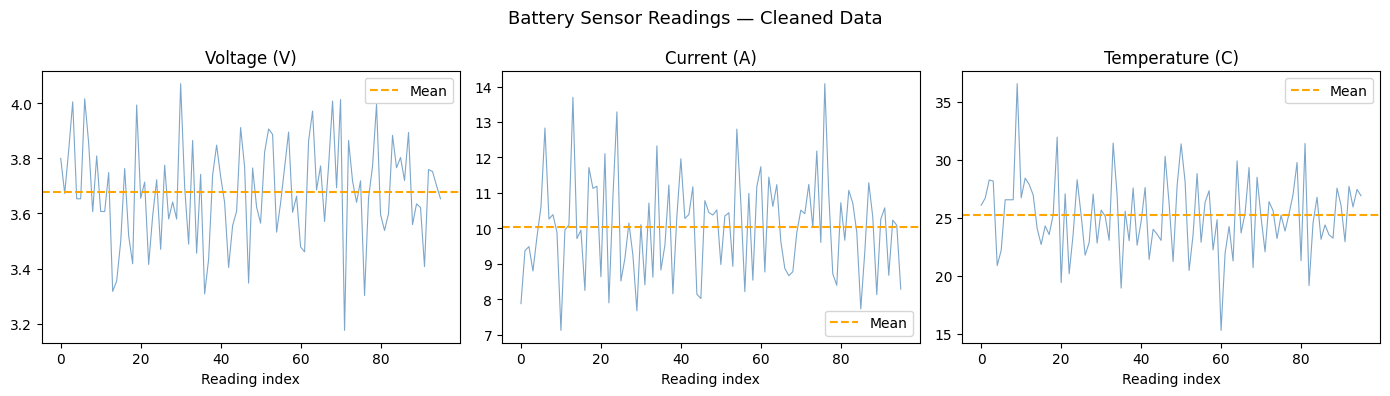

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, name) in enumerate(zip(axes, sensor_names)):
    ax.plot(clean_data[:, i], color='steelblue', linewidth=0.8, alpha=0.7)
    ax.axhline(means[0, i], color='orange', linestyle='--', label='Mean')
    ax.set_title(name)
    ax.set_xlabel('Reading index')
    ax.legend()

plt.suptitle('Battery Sensor Readings — Cleaned Data', fontsize=13)
plt.tight_layout()
plt.savefig('sensor_analysis.png', dpi=150)
plt.show()